# 04 -- Ridge


Мы решаем регрессию задержки `target_delay_s`; основная метрика -- MAE в секундах.

Здесь я использую более строгий протокол, чем обычный random split:

* в train реальные ТС и synthetic ТС разделены по `tr_id`; synthetic имеют ID `9000000+`;
* test и validate состоят из реальных ТС, причем их `tr_id` уже встречаются в train;
* основной CV поэтому строю внутри реальных ТС блоками по времени;
* вокруг validation блока удаляю train точки того же ТС в радиусе 45 минут -- это покрывает максимальные 30 минут истории признаков и 15 минут prediction horizon;
* synthetic никогда не попадает в validation -- его вес в train подбираю как гиперпараметр;
* `test` не использую ни в Optuna, ни в выборе direct/residual -- открываю его один раз после фиксации модели;
* после этой проверки test можно легально добавить к train и отдельно донастроить финальную модель для hidden validate.

Глобальные `pca_core_*` из `02_feature_engineering.ipynb` в CV не использую: PCA там fit'ился на всем train. Для честной оценки любое обучаемое преобразование должно fit'иться только внутри fold.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

RIDGE_SEED = 143
RIDGE_TUNE_FOLDS = 4
RIDGE_OOF_FOLDS = 5
RIDGE_STRESS_FOLDS = 5
RIDGE_PURGE_MINUTES = 45
RIDGE_TRIALS_PER_MODE = 60
RIDGE_FINAL_TRIALS = 25
RIDGE_MODES = ['direct', 'residual']
RIDGE_SYNTHETIC_WEIGHTS = [0.0, .1, .25, .5, .75, 1.0]
RIDGE_CLIP_Q = [0.0, .001, .005, .01, .02]

## 1. Данные и audit

Я читаю только артефакты `02_feature_engineering.ipynb`. `test` пока остается закрытым.

Из model features удаляю сохраненные `pca_core_*`. Остальные преобразования из `02_` либо детерминированы из строки, либо не используют target. PCA -- единственный явный fit на всем train, поэтому его пересобираю внутри fold как отдельную ветку Ridge.

In [14]:
ridge_features_dir = Path('../dataset/features')

ridge_train = pd.read_pickle(ridge_features_dir / 'train_features.pkl').reset_index(drop=True)
ridge_test = pd.read_pickle(ridge_features_dir / 'test_features.pkl').reset_index(drop=True)
ridge_validate = pd.read_pickle(ridge_features_dir / 'validate_features.pkl').reset_index(drop=True)

ridge_saved_features = pd.read_csv(ridge_features_dir / 'feature_columns.csv').feature.tolist()
ridge_saved_categorical = pd.read_csv(ridge_features_dir / 'categorical_features.csv').feature.tolist()

ridge_feature_cols = [
    ridge_col for ridge_col in ridge_saved_features
    if not ridge_col.startswith('pca_core_')
]
ridge_categorical_features = [
    ridge_col for ridge_col in ridge_saved_categorical
    if ridge_col in ridge_feature_cols
]
ridge_numeric_features = [
    ridge_col for ridge_col in ridge_feature_cols
    if ridge_col not in ridge_categorical_features
    and pd.api.types.is_numeric_dtype(ridge_train[ridge_col].dtype)
]

RIDGE_PCA_CORE = [
    ridge_col for ridge_col in [
        'cur_dev_s', 'horizon_min', 'last_valid_speed_kmh', 'valid_age_s',
        'last_receive_lag_s', 'distance_to_target_m', 'required_speed_kmh',
        'route_proxy_m', 'route_proxy_required_speed_kmh', 'speed_margin_kmh',
        'route_speed_margin_kmh', 'eta_margin_last_speed_s',
        'w5m_speed_mean', 'w5m_speed_std', 'w5m_target_progress_kmh',
        'w15m_speed_mean', 'w15m_valid_share', 'w15m_target_progress_kmh',
        'stop_lon', 'stop_lat', 'target_time_sin', 'target_time_cos'
    ]
    if ridge_col in ridge_numeric_features
]

assert not {'target_delay_s', 'target_class'} & set(ridge_feature_cols)
assert not any(ridge_col.startswith('pca_core_') for ridge_col in ridge_feature_cols)
assert set(ridge_train.sample_id).isdisjoint(set(ridge_test.sample_id))
assert set(ridge_train.sample_id).isdisjoint(set(ridge_validate.sample_id))
assert ridge_train.cur_dev_s.notna().all()
assert ridge_test.cur_dev_s.notna().all()
assert ridge_validate.cur_dev_s.notna().all()

pd.Series({
    'train_rows': len(ridge_train),
    'train_real_rows': (ridge_train.tr_id < 9_000_000).sum(),
    'train_synthetic_rows': (ridge_train.tr_id >= 9_000_000).sum(),
    'test_rows': len(ridge_test),
    'validate_rows': len(ridge_validate),
    'numeric_features': len(ridge_numeric_features),
    'categorical_features': len(ridge_categorical_features),
    'dropped_global_pca': sum(ridge_col.startswith('pca_core_') for ridge_col in ridge_saved_features),
})

train_rows              4434
train_real_rows         1141
train_synthetic_rows    3293
test_rows                353
validate_rows            151
numeric_features         680
categorical_features      12
dropped_global_pca        14
dtype: int64

## 2. Leakage safe CV

Основной splitter имитирует структуру hidden validate лучше, чем `GroupKFold`: у каждого реального ТС я делю точки на последовательные временные блоки. Validation fold содержит один блок от каждого реального ТС. Из train дополнительно вычищаю точки того же ТС на 45 минут до и после validation блока.

Synthetic остается только в train. Так Optuna оценивает гиперпараметры на реальных точках, но может решить, помогает ли дополнительная синтетика.

Дополнительно после tuning запускаю `GroupKFold` по реальным `tr_id` как stress-test -- он отвечает на более строгий вопрос о переносе на полностью невиданное ТС, хотя hidden validate устроен не так.

In [15]:
def ridge_build_purged_folds(data, n_splits, purge_minutes):
    ridge_frame = data[['tr_id', 'T']].copy().reset_index(drop=True)
    ridge_frame['T'] = pd.to_datetime(ridge_frame['T'])
    ridge_frame['is_synthetic'] = ridge_frame.tr_id >= 9_000_000
    ridge_frame['cv_fold'] = -1

    for ridge_tr_id, ridge_idx in ridge_frame.loc[~ridge_frame.is_synthetic].groupby('tr_id').groups.items():
        ridge_ordered = ridge_frame.loc[ridge_idx].sort_values('T').index.to_numpy()
        for ridge_fold, ridge_chunk in enumerate(np.array_split(ridge_ordered, n_splits)):
            ridge_frame.loc[ridge_chunk, 'cv_fold'] = ridge_fold

    ridge_folds = []
    ridge_purge = pd.Timedelta(minutes=purge_minutes)

    for ridge_fold in range(n_splits):
        ridge_valid_mask = (~ridge_frame.is_synthetic) & (ridge_frame.cv_fold == ridge_fold)
        ridge_train_mask = ~ridge_valid_mask

        for ridge_tr_id, ridge_valid_part in ridge_frame.loc[ridge_valid_mask].groupby('tr_id'):
            ridge_left = ridge_valid_part['T'].min() - ridge_purge
            ridge_right = ridge_valid_part['T'].max() + ridge_purge
            ridge_near_valid = (
                (~ridge_frame.is_synthetic)
                & (ridge_frame.tr_id == ridge_tr_id)
                & ridge_frame['T'].between(ridge_left, ridge_right)
            )
            ridge_train_mask &= ~ridge_near_valid

        ridge_folds.append((
            np.flatnonzero(ridge_train_mask.to_numpy()),
            np.flatnonzero(ridge_valid_mask.to_numpy())
        ))

    return ridge_folds


def ridge_build_group_stress_folds(data, n_splits):
    ridge_real_idx = np.flatnonzero((data.tr_id < 9_000_000).to_numpy())
    ridge_synthetic_idx = np.flatnonzero((data.tr_id >= 9_000_000).to_numpy())
    ridge_splitter = GroupKFold(n_splits=n_splits, shuffle=True, random_state=RIDGE_SEED)
    ridge_folds = []

    for ridge_real_train_local, ridge_real_valid_local in ridge_splitter.split(
        ridge_real_idx,
        groups=data.iloc[ridge_real_idx].tr_id
    ):
        ridge_train_idx = np.concatenate([
            ridge_real_idx[ridge_real_train_local],
            ridge_synthetic_idx
        ])
        ridge_valid_idx = ridge_real_idx[ridge_real_valid_local]
        ridge_folds.append((ridge_train_idx, ridge_valid_idx))

    return ridge_folds


def ridge_check_purged_folds(data, folds, purge_minutes):
    ridge_frame = data[['tr_id', 'T']].copy().reset_index(drop=True)
    ridge_frame['T'] = pd.to_datetime(ridge_frame['T'])
    ridge_purge = pd.Timedelta(minutes=purge_minutes)
    ridge_rows = []

    for ridge_fold, (ridge_train_idx, ridge_valid_idx) in enumerate(folds):
        ridge_train = ridge_frame.iloc[ridge_train_idx]
        ridge_valid = ridge_frame.iloc[ridge_valid_idx]
        ridge_min_gap = np.inf

        for ridge_tr_id, ridge_valid_part in ridge_valid.groupby('tr_id'):
            ridge_train_times = ridge_train.loc[ridge_train.tr_id == ridge_tr_id, 'T']
            if len(ridge_train_times) == 0:
                continue
            ridge_gap = np.abs(
                ridge_train_times.to_numpy()[:, None]
                - ridge_valid_part['T'].to_numpy()[None, :]
            ).min()
            ridge_min_gap = min(ridge_min_gap, ridge_gap / np.timedelta64(1, 'm'))

        ridge_rows.append({
            'fold': ridge_fold,
            'train_rows': len(ridge_train_idx),
            'valid_rows': len(ridge_valid_idx),
            'valid_tr_ids': ridge_valid.tr_id.nunique(),
            'min_same_tr_gap_min': ridge_min_gap
        })

    ridge_result = pd.DataFrame(ridge_rows)
    assert (ridge_result.min_same_tr_gap_min >= purge_minutes).all()
    return ridge_result

In [16]:
ridge_tune_folds = ridge_build_purged_folds(
    ridge_train,
    RIDGE_TUNE_FOLDS,
    RIDGE_PURGE_MINUTES
)
ridge_oof_folds = ridge_build_purged_folds(
    ridge_train,
    RIDGE_OOF_FOLDS,
    RIDGE_PURGE_MINUTES
)
ridge_stress_folds = ridge_build_group_stress_folds(
    ridge_train,
    RIDGE_STRESS_FOLDS
)

ridge_fold_audit = ridge_check_purged_folds(
    ridge_train,
    ridge_oof_folds,
    RIDGE_PURGE_MINUTES
)
ridge_fold_audit

,fold,train_rows,valid_rows,valid_tr_ids,min_same_tr_gap_min
0,0,4130,233,13,50.0
1,1,4042,231,13,50.0
2,2,4082,228,13,50.0
3,3,4060,226,13,50.0
4,4,4149,223,13,50.0


## 3. Fold safe preprocessing

Ridge чувствителен к масштабу, пропускам и кодированию категорий. Все это fit'ю только на train части fold.

Optuna может включить one hot категории и дополнительный PCA по физически осмысленному ядру. PCA здесь уже честный -- imputer, scaler и компоненты заново fit'ятся внутри каждого fold.

In [17]:
def ridge_prepare_frame(data):
    ridge_frame = data[ridge_numeric_features + ridge_categorical_features].copy()
    for ridge_col in ridge_categorical_features:
        ridge_frame[ridge_col] = (
            ridge_frame[ridge_col]
            .astype('string')
            .fillna('__missing__')
            .astype(str)
        )
    return ridge_frame


def ridge_make_preprocessor(params):
    ridge_scaler = (
        StandardScaler()
        if params['scaler'] == 'standard'
        else RobustScaler(quantile_range=(10, 90))
    )
    ridge_numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(
            strategy=params['imputer'],
            add_indicator=params['missing_indicators']
        )),
        ('scaler', ridge_scaler)
    ])
    ridge_transformers = [
        ('numeric', ridge_numeric_pipe, ridge_numeric_features)
    ]

    if params['use_categorical'] and ridge_categorical_features:
        ridge_transformers.append((
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                min_frequency=params['ohe_min_frequency'],
                dtype=np.float32
            ),
            ridge_categorical_features
        ))

    if params['use_pca'] and RIDGE_PCA_CORE:
        ridge_transformers.append((
            'pca',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('pca', PCA(
                    n_components=params['pca_components'],
                    random_state=RIDGE_SEED
                ))
            ]),
            RIDGE_PCA_CORE
        ))

    return ColumnTransformer(
        ridge_transformers,
        remainder='drop',
        sparse_threshold=.8
    )


def ridge_sample_weight(data, synthetic_weight):
    return np.where(
        data.tr_id.to_numpy() >= 9_000_000,
        synthetic_weight,
        1.0
    )


def ridge_clip_prediction(prediction, y_train, q):
    if q == 0:
        return prediction
    ridge_low, ridge_high = y_train.quantile([q, 1 - q])
    return np.clip(prediction, ridge_low, ridge_high)

In [18]:
ridge_x_train = ridge_prepare_frame(ridge_train)
ridge_x_test = ridge_prepare_frame(ridge_test)
ridge_x_validate = ridge_prepare_frame(ridge_validate)

ridge_y_train = ridge_train.target_delay_s.astype(float)
ridge_y_test = ridge_test.target_delay_s.astype(float)
ridge_cur_train = ridge_train.cur_dev_s.astype(float)
ridge_cur_test = ridge_test.cur_dev_s.astype(float)
ridge_cur_validate = ridge_validate.cur_dev_s.astype(float)

## 4. Optuna -- hyperparameter search

Direct и residual оптимизирую отдельными studies -- так каждый режим получает одинаковый бюджет.

Кроме параметров Ridge подбираю:

* силу synthetic данных;
* тип scaling и imputation;
* использование категорий;
* fold safe PCA;
* мягкий clipping по квантилям train target -- только как postprocessing для MAE.

In [19]:
def ridge_suggest_params(trial):
    ridge_params = {
        'alpha': trial.suggest_float('alpha', 1e-3, 1e5, log=True),
        'tol': trial.suggest_float('tol', 1e-7, 1e-3, log=True),
        'imputer': trial.suggest_categorical('imputer', ['median', 'mean']),
        'scaler': trial.suggest_categorical('scaler', ['standard', 'robust']),
        'missing_indicators': trial.suggest_categorical('missing_indicators', [False, True]),
        'use_categorical': trial.suggest_categorical('use_categorical', [False, True]),
        'use_pca': trial.suggest_categorical('use_pca', [False, True]),
        'synthetic_weight': trial.suggest_categorical('synthetic_weight', RIDGE_SYNTHETIC_WEIGHTS),
        'clip_q': trial.suggest_categorical('clip_q', RIDGE_CLIP_Q),
    }
    if ridge_params['use_categorical']:
        ridge_params['ohe_min_frequency'] = trial.suggest_categorical(
            'ohe_min_frequency', [2, 5, 10, 20]
        )
    else:
        ridge_params['ohe_min_frequency'] = 5

    if ridge_params['use_pca']:
        ridge_params['pca_components'] = trial.suggest_int(
            'pca_components',
            4,
            min(16, len(RIDGE_PCA_CORE))
        )
    else:
        ridge_params['pca_components'] = min(8, len(RIDGE_PCA_CORE))

    return ridge_params


def ridge_objective(trial, mode, data, x, y, cur_dev, folds):
    ridge_params = ridge_suggest_params(trial)
    ridge_scores = []

    for ridge_fold, (ridge_train_idx, ridge_valid_idx) in enumerate(folds):
        ridge_train_part = data.iloc[ridge_train_idx]
        ridge_weights = ridge_sample_weight(
            ridge_train_part,
            ridge_params['synthetic_weight']
        )
        ridge_active = ridge_weights > 0

        ridge_preprocessor = ridge_make_preprocessor(ridge_params)
        ridge_train_matrix = ridge_preprocessor.fit_transform(
            x.iloc[ridge_train_idx].loc[ridge_active]
        )
        ridge_valid_matrix = ridge_preprocessor.transform(x.iloc[ridge_valid_idx])

        ridge_fit_target = y.iloc[ridge_train_idx].loc[ridge_active].copy()
        if mode == 'residual':
            ridge_fit_target = (
                ridge_fit_target
                - cur_dev.iloc[ridge_train_idx].loc[ridge_active]
            )

        ridge_model = Ridge(
            alpha=ridge_params['alpha'],
            tol=ridge_params['tol'],
            solver='lsqr',
            max_iter=20_000
        )
        ridge_model.fit(
            ridge_train_matrix,
            ridge_fit_target,
            sample_weight=ridge_weights[ridge_active]
        )

        ridge_prediction = ridge_model.predict(ridge_valid_matrix)
        if mode == 'residual':
            ridge_prediction += cur_dev.iloc[ridge_valid_idx].to_numpy()

        ridge_prediction = ridge_clip_prediction(
            ridge_prediction,
            y.iloc[ridge_train_idx].loc[ridge_active],
            ridge_params['clip_q']
        )
        ridge_scores.append(mean_absolute_error(
            y.iloc[ridge_valid_idx],
            ridge_prediction
        ))

        trial.report(np.mean(ridge_scores), step=ridge_fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(ridge_scores))

In [20]:
ridge_artifact_dir = Path('../artifacts/models/ridge')
ridge_artifact_dir.mkdir(parents=True, exist_ok=True)
ridge_storage = f"sqlite:///{(ridge_artifact_dir / 'optuna.db').resolve()}"

ridge_studies = {}

for ridge_mode in RIDGE_MODES:
    ridge_study = optuna.create_study(
        study_name=f'ridge_{ridge_mode}_train',
        storage=ridge_storage,
        load_if_exists=True,
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RIDGE_SEED),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=10,
            n_warmup_steps=1
        )
    )
    ridge_finished = sum(
        ridge_trial.state in {
            optuna.trial.TrialState.COMPLETE,
            optuna.trial.TrialState.PRUNED
        }
        for ridge_trial in ridge_study.trials
    )
    ridge_remaining = max(0, RIDGE_TRIALS_PER_MODE - ridge_finished)
    if ridge_remaining:
        ridge_study.optimize(
            lambda ridge_trial, ridge_mode=ridge_mode: ridge_objective(
                ridge_trial,
                ridge_mode,
                ridge_train,
                ridge_x_train,
                ridge_y_train,
                ridge_cur_train,
                ridge_tune_folds
            ),
            n_trials=ridge_remaining,
            n_jobs=1,
            show_progress_bar=True
        )
    ridge_studies[ridge_mode] = ridge_study

[I 2026-09-26 21:47:50,853] Using an existing study with `study_name='ridge_direct_train'` instead of creating a new one.


[I 2026-09-26 21:47:50,914] Using an existing study with `study_name='ridge_residual_train'` instead of creating a new one.


In [21]:
def ridge_study_summary(studies):
    ridge_rows = []
    for ridge_mode, ridge_study in studies.items():
        ridge_complete = [
            ridge_trial for ridge_trial in ridge_study.trials
            if ridge_trial.state == optuna.trial.TrialState.COMPLETE
        ]
        ridge_rows.append({
            'mode': ridge_mode,
            'trials': len(ridge_study.trials),
            'complete': len(ridge_complete),
            'best_cv_mae': ridge_study.best_value
        })
    return pd.DataFrame(ridge_rows).sort_values('best_cv_mae')


def ridge_plot_study(study, title):
    ridge_completed = pd.DataFrame([
        {
            'number': ridge_trial.number,
            'value': ridge_trial.value
        }
        for ridge_trial in study.trials
        if ridge_trial.state == optuna.trial.TrialState.COMPLETE
    ]).sort_values('number')
    ridge_completed['best_so_far'] = ridge_completed.value.cummin()

    ridge_fig, ridge_axes = plt.subplots(1, 2, figsize=(14, 4))
    ridge_axes[0].scatter(ridge_completed.number, ridge_completed.value, s=24, alpha=.65)
    ridge_axes[0].plot(ridge_completed.number, ridge_completed.best_so_far, linewidth=2)
    ridge_axes[0].set_title(f'{title} -- optimization history')
    ridge_axes[0].set_xlabel('trial')
    ridge_axes[0].set_ylabel('CV MAE, sec')

    ridge_importance = optuna.importance.get_param_importances(study)
    pd.Series(ridge_importance).sort_values().plot.barh(ax=ridge_axes[1])
    ridge_axes[1].set_title(f'{title} -- Optuna param importance')
    ridge_axes[1].set_xlabel('importance')
    plt.tight_layout()

In [22]:
ridge_study_table = ridge_study_summary(ridge_studies)
ridge_study_table

,mode,trials,complete,best_cv_mae
1,residual,61,46,64.296687
0,direct,60,45,64.862239


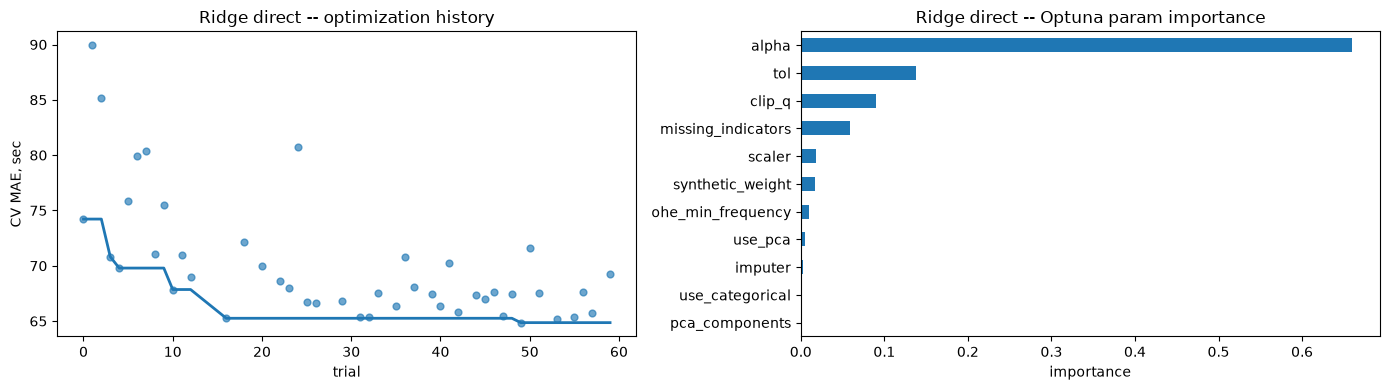

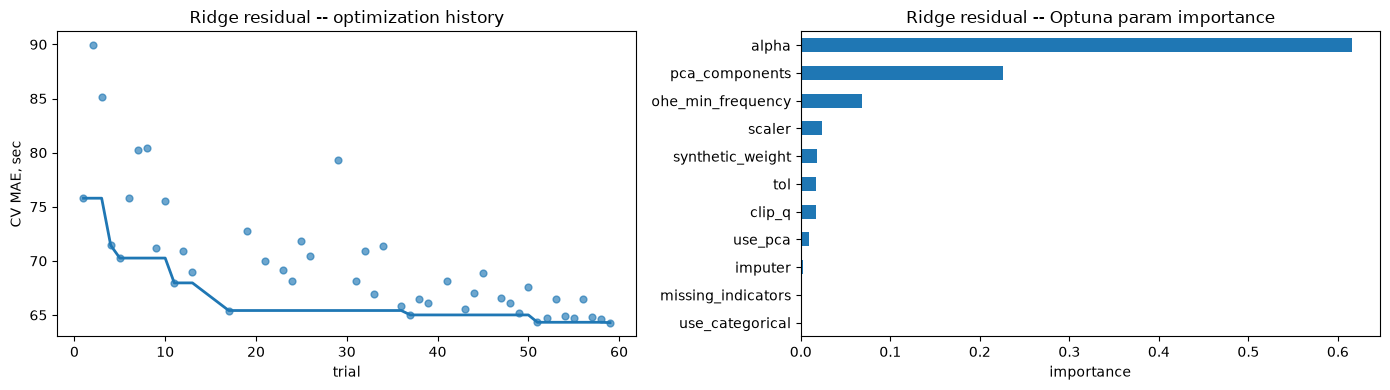

In [23]:
for ridge_mode, ridge_study in ridge_studies.items():
    ridge_plot_study(ridge_study, f'Ridge {ridge_mode}')

In [24]:
ridge_best_mode = ridge_study_table.iloc[0]['mode']
ridge_best_study = ridge_studies[ridge_best_mode]
ridge_best_params = ridge_suggest_params(ridge_best_study.best_trial)

pd.Series(ridge_best_params, name='value').to_frame()

,value
alpha,16.149203
tol,0.000082
imputer,median
scaler,robust
missing_indicators,False
use_categorical,True
use_pca,False
synthetic_weight,1.0
clip_q,0.02
ohe_min_frequency,5


## 5. OOF с выбранными параметрами

После Optuna фиксирую режим и гиперпараметры. На 5 purged folds строю OOF predictions и смотрю не только средний MAE, но и разброс по времени и по отдельным реальным ТС.

In [25]:
def ridge_fit_fold(data, x, y, cur_dev, train_idx, valid_idx, mode, params):
    ridge_train_part = data.iloc[train_idx]
    ridge_weights = ridge_sample_weight(ridge_train_part, params['synthetic_weight'])
    ridge_active = ridge_weights > 0

    ridge_preprocessor = ridge_make_preprocessor(params)
    ridge_train_matrix = ridge_preprocessor.fit_transform(
        x.iloc[train_idx].loc[ridge_active]
    )
    ridge_valid_matrix = ridge_preprocessor.transform(x.iloc[valid_idx])

    ridge_fit_target = y.iloc[train_idx].loc[ridge_active].copy()
    if mode == 'residual':
        ridge_fit_target = ridge_fit_target - cur_dev.iloc[train_idx].loc[ridge_active]

    ridge_model = Ridge(
        alpha=params['alpha'],
        tol=params['tol'],
        solver='lsqr',
        max_iter=20_000
    )
    ridge_model.fit(
        ridge_train_matrix,
        ridge_fit_target,
        sample_weight=ridge_weights[ridge_active]
    )

    ridge_prediction = ridge_model.predict(ridge_valid_matrix)
    if mode == 'residual':
        ridge_prediction += cur_dev.iloc[valid_idx].to_numpy()

    ridge_prediction = ridge_clip_prediction(
        ridge_prediction,
        y.iloc[train_idx].loc[ridge_active],
        params['clip_q']
    )
    return ridge_model, ridge_preprocessor, ridge_prediction


def ridge_oof_predict(data, x, y, cur_dev, folds, mode, params):
    ridge_parts = []
    ridge_models = []

    for ridge_fold, (ridge_train_idx, ridge_valid_idx) in enumerate(folds):
        ridge_model, ridge_preprocessor, ridge_prediction = ridge_fit_fold(
            data, x, y, cur_dev,
            ridge_train_idx, ridge_valid_idx,
            mode, params
        )
        ridge_part = data.iloc[ridge_valid_idx][['sample_id', 'tr_id', 'T']].copy()
        ridge_part['fold'] = ridge_fold
        ridge_part['target'] = y.iloc[ridge_valid_idx].to_numpy()
        ridge_part['prediction'] = ridge_prediction
        ridge_part['error'] = ridge_part.target - ridge_part.prediction
        ridge_part['abs_error'] = ridge_part.error.abs()
        ridge_parts.append(ridge_part)
        ridge_models.append((ridge_model, ridge_preprocessor))

    return pd.concat(ridge_parts, ignore_index=True), ridge_models

In [26]:
ridge_oof, ridge_oof_models = ridge_oof_predict(
    ridge_train,
    ridge_x_train,
    ridge_y_train,
    ridge_cur_train,
    ridge_oof_folds,
    ridge_best_mode,
    ridge_best_params
)

pd.Series({
    'oof_mae': ridge_oof.abs_error.mean(),
    'oof_median_abs_error': ridge_oof.abs_error.median(),
    'oof_p90_abs_error': ridge_oof.abs_error.quantile(.9),
    'cur_dev_mae_same_rows': mean_absolute_error(
        ridge_oof.target,
        ridge_train.set_index('sample_id').loc[ridge_oof.sample_id, 'cur_dev_s']
    )
})

oof_mae                   63.842696
oof_median_abs_error      50.771871
oof_p90_abs_error        136.664833
cur_dev_mae_same_rows     86.837862
dtype: float64

In [27]:
def ridge_plot_oof(oof):
    ridge_fig, ridge_axes = plt.subplots(2, 2, figsize=(14, 10))

    ridge_axes[0, 0].scatter(oof.target, oof.prediction, s=18, alpha=.4)
    ridge_axes[0, 0].axline((0, 0), slope=1, linestyle='--', linewidth=1)
    ridge_axes[0, 0].set_title('OOF -- prediction vs target')
    ridge_axes[0, 0].set_xlabel('target, sec')
    ridge_axes[0, 0].set_ylabel('prediction, sec')

    ridge_axes[0, 1].hist(oof.error, bins=60)
    ridge_axes[0, 1].axvline(0, linewidth=1)
    ridge_axes[0, 1].set_title('OOF -- error distribution')
    ridge_axes[0, 1].set_xlabel('target - prediction, sec')

    ridge_fold_mae = oof.groupby('fold').abs_error.mean()
    ridge_fold_mae.plot.bar(ax=ridge_axes[1, 0])
    ridge_axes[1, 0].set_title('MAE по fold')
    ridge_axes[1, 0].set_ylabel('MAE, sec')
    ridge_axes[1, 0].tick_params(axis='x', rotation=0)

    ridge_tr_mae = oof.groupby('tr_id').abs_error.mean().sort_values()
    ridge_tr_mae.plot.barh(ax=ridge_axes[1, 1])
    ridge_axes[1, 1].set_title('MAE по real tr_id')
    ridge_axes[1, 1].set_xlabel('MAE, sec')

    plt.tight_layout()

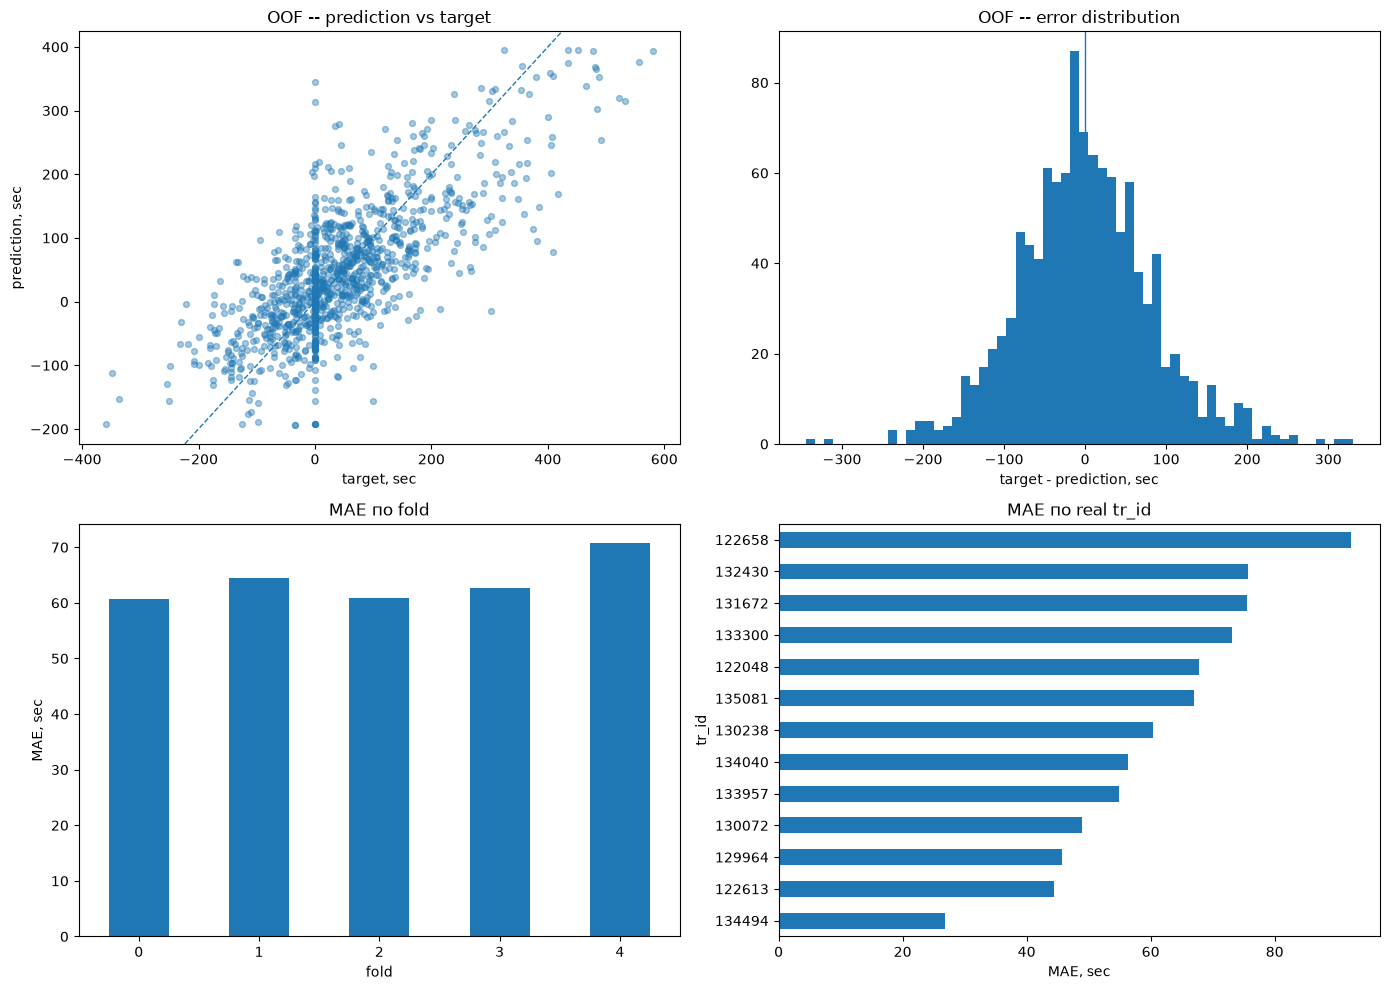

In [28]:
ridge_plot_oof(ridge_oof)

## 6. Stress-test на невиданных ТС

Это не основной CV для hidden validate, но полезная проверка устойчивости. В каждом fold validation содержит целые реальные `tr_id`, которых модель не видит в train.

In [29]:
ridge_stress_oof, ridge_stress_models = ridge_oof_predict(
    ridge_train,
    ridge_x_train,
    ridge_y_train,
    ridge_cur_train,
    ridge_stress_folds,
    ridge_best_mode,
    ridge_best_params
)

pd.Series({
    'purged_oof_mae': ridge_oof.abs_error.mean(),
    'unseen_tr_id_mae': ridge_stress_oof.abs_error.mean()
})

purged_oof_mae      63.842696
unseen_tr_id_mae    65.042887
dtype: float64

## 7. Learning curve

Learning curve строю на первом purged fold, а не на test. Размер train меняю только среди real точек; synthetic оставляю доступным с найденным весом. Так test по прежнему остается нетронутым.

In [30]:
def ridge_fraction_mask(data, train_idx, fraction, seed):
    ridge_part = data.iloc[train_idx]
    ridge_real_idx = ridge_part.index[ridge_part.tr_id < 9_000_000].to_numpy()
    ridge_synthetic_idx = ridge_part.index[ridge_part.tr_id >= 9_000_000].to_numpy()
    ridge_rng = np.random.default_rng(seed)
    ridge_score = pd.Series(ridge_rng.random(len(ridge_real_idx)), index=ridge_real_idx)
    ridge_selected_real = ridge_score.index[ridge_score <= fraction].to_numpy()
    return np.concatenate([ridge_selected_real, ridge_synthetic_idx])

In [31]:
def ridge_learning_curve(data, x, y, cur_dev, fold, mode, params, fractions):
    ridge_train_idx, ridge_valid_idx = fold
    ridge_rows = []

    for ridge_fraction in fractions:
        ridge_fraction_idx = ridge_fraction_mask(
            data,
            ridge_train_idx,
            ridge_fraction,
            RIDGE_SEED
        )
        _, _, ridge_prediction = ridge_fit_fold(
            data, x, y, cur_dev,
            ridge_fraction_idx,
            ridge_valid_idx,
            mode, params
        )
        ridge_rows.append({
            'real_fraction': ridge_fraction,
            'train_rows': len(ridge_fraction_idx),
            'valid_mae': mean_absolute_error(
                y.iloc[ridge_valid_idx],
                ridge_prediction
            )
        })

    return pd.DataFrame(ridge_rows)

In [32]:
ridge_learning = ridge_learning_curve(
    ridge_train,
    ridge_x_train,
    ridge_y_train,
    ridge_cur_train,
    ridge_oof_folds[0],
    ridge_best_mode,
    ridge_best_params,
    [.2, .4, .6, .8, 1.0]
)
ridge_learning

,real_fraction,train_rows,valid_mae
0,0.2,3458,61.773982
1,0.4,3620,60.826354
2,0.6,3793,60.668785
3,0.8,3957,59.938343
4,1.0,4130,60.686530


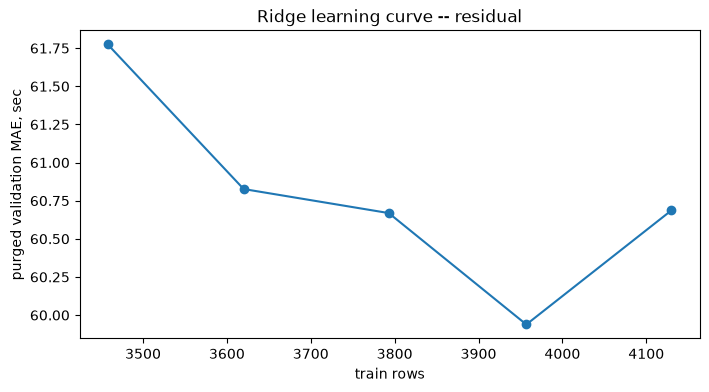

In [33]:
plt.figure(figsize=(8, 4))
plt.plot(ridge_learning.train_rows, ridge_learning.valid_mae, marker='o')
plt.title(f'Ridge learning curve -- {ridge_best_mode}')
plt.xlabel('train rows')
plt.ylabel('purged validation MAE, sec')
plt.show()

## 8. Official test -- открываю один раз

К этому моменту mode, гиперпараметры и postprocessing уже зафиксированы по train CV. Теперь fit'юсь на всем train и один раз измеряю качество на `labels_test`.

In [34]:
def ridge_fit_full_predict(train_data, train_x, train_y, train_cur, eval_x, eval_cur, mode, params):
    ridge_weights = ridge_sample_weight(train_data, params['synthetic_weight'])
    ridge_active = ridge_weights > 0
    ridge_preprocessor = ridge_make_preprocessor(params)
    ridge_train_matrix = ridge_preprocessor.fit_transform(train_x.loc[ridge_active])
    ridge_eval_matrix = ridge_preprocessor.transform(eval_x)

    ridge_fit_target = train_y.loc[ridge_active].copy()
    if mode == 'residual':
        ridge_fit_target = ridge_fit_target - train_cur.loc[ridge_active]

    ridge_model = Ridge(
        alpha=params['alpha'],
        tol=params['tol'],
        solver='lsqr',
        max_iter=20_000
    )
    ridge_model.fit(
        ridge_train_matrix,
        ridge_fit_target,
        sample_weight=ridge_weights[ridge_active]
    )

    ridge_prediction = ridge_model.predict(ridge_eval_matrix)
    if mode == 'residual':
        ridge_prediction += eval_cur.to_numpy()

    ridge_prediction = ridge_clip_prediction(
        ridge_prediction,
        train_y.loc[ridge_active],
        params['clip_q']
    )
    return ridge_model, ridge_preprocessor, ridge_prediction

In [35]:
ridge_test_model, ridge_test_preprocessor, ridge_test_prediction = ridge_fit_full_predict(
    ridge_train,
    ridge_x_train,
    ridge_y_train,
    ridge_cur_train,
    ridge_x_test,
    ridge_cur_test,
    ridge_best_mode,
    ridge_best_params
)

ridge_test_metrics = pd.Series({
    'ridge_test_mae': mean_absolute_error(ridge_y_test, ridge_test_prediction),
    'cur_dev_test_mae': mean_absolute_error(ridge_y_test, ridge_cur_test),
    'improvement_sec': mean_absolute_error(ridge_y_test, ridge_cur_test)
        - mean_absolute_error(ridge_y_test, ridge_test_prediction)
})
ridge_test_metrics

ridge_test_mae      65.909102
cur_dev_test_mae    93.359773
improvement_sec     27.450671
dtype: float64

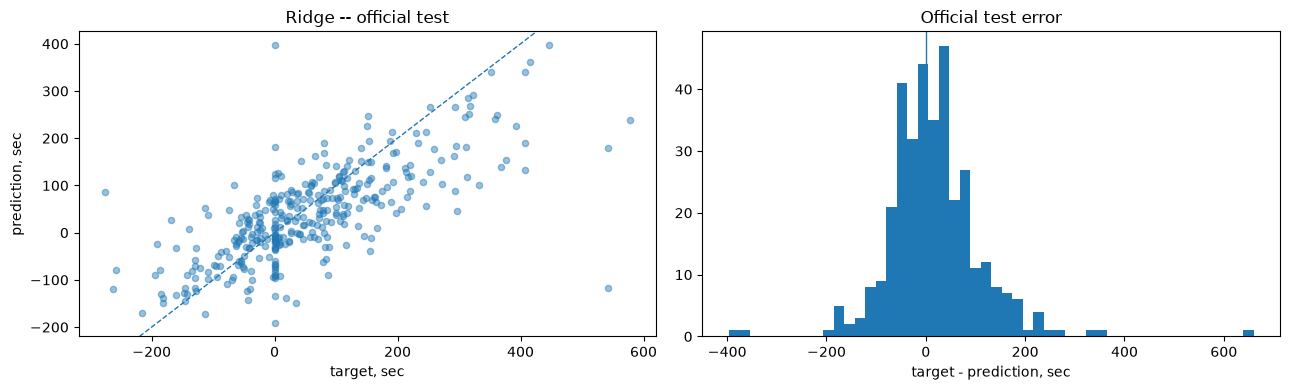

In [36]:
ridge_test_error = ridge_y_test.to_numpy() - ridge_test_prediction
ridge_fig, ridge_axes = plt.subplots(1, 2, figsize=(13, 4))
ridge_axes[0].scatter(ridge_y_test, ridge_test_prediction, s=20, alpha=.45)
ridge_axes[0].axline((0, 0), slope=1, linestyle='--', linewidth=1)
ridge_axes[0].set_title('Ridge -- official test')
ridge_axes[0].set_xlabel('target, sec')
ridge_axes[0].set_ylabel('prediction, sec')
ridge_axes[1].hist(ridge_test_error, bins=50)
ridge_axes[1].axvline(0, linewidth=1)
ridge_axes[1].set_title('Official test error')
ridge_axes[1].set_xlabel('target - prediction, sec')
plt.tight_layout()

## 9. Final retune на train + test

После фиксации test результата я больше не трактую test как holdout. Для финального validate объединяю все доступные labels и запускаю короткий второй Optuna search в той же постановке. Mode оставляю тем, который был выбран до открытия test.

In [37]:
ridge_all = pd.concat([ridge_train, ridge_test], ignore_index=True)
ridge_x_all = ridge_prepare_frame(ridge_all)
ridge_y_all = ridge_all.target_delay_s.astype(float)
ridge_cur_all = ridge_all.cur_dev_s.astype(float)
ridge_final_folds = ridge_build_purged_folds(
    ridge_all,
    RIDGE_OOF_FOLDS,
    RIDGE_PURGE_MINUTES
)

ridge_final_study = optuna.create_study(
    study_name=f'ridge_{ridge_best_mode}_final',
    storage=ridge_storage,
    load_if_exists=True,
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RIDGE_SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)
if len(ridge_final_study.trials) == 0:
    ridge_final_study.enqueue_trial(ridge_best_study.best_params)

ridge_final_finished = sum(
    ridge_trial.state in {
        optuna.trial.TrialState.COMPLETE,
        optuna.trial.TrialState.PRUNED
    }
    for ridge_trial in ridge_final_study.trials
)
ridge_final_remaining = max(0, RIDGE_FINAL_TRIALS - ridge_final_finished)
if ridge_final_remaining:
    ridge_final_study.optimize(
        lambda ridge_trial: ridge_objective(
            ridge_trial,
            ridge_best_mode,
            ridge_all,
            ridge_x_all,
            ridge_y_all,
            ridge_cur_all,
            ridge_final_folds
        ),
        n_trials=ridge_final_remaining,
        n_jobs=1,
        show_progress_bar=True
    )

ridge_final_params = ridge_suggest_params(ridge_final_study.best_trial)
pd.Series(ridge_final_params, name='value').to_frame()

[I 2026-09-26 21:48:22,677] A new study created in RDB with name: ridge_residual_final
Best trial: 0. Best value: 64.5207:   4%|▍         | 1/25 [00:09<03:47,  9.49s/it]

[I 2026-09-26 21:48:32,177] Trial 0 finished with value: 64.52068643893449 and parameters: {'alpha': 16.14920331159824, 'tol': 8.241219513867579e-05, 'imputer': 'median', 'scaler': 'robust', 'missing_indicators': False, 'use_categorical': True, 'use_pca': False, 'synthetic_weight': 1.0, 'clip_q': 0.02, 'ohe_min_frequency': 5}. Best is trial 0 with value: 64.52068643893449.


Best trial: 0. Best value: 64.5207:   8%|▊         | 2/25 [00:13<02:18,  6.02s/it]

[I 2026-09-26 21:48:35,778] Trial 1 finished with value: 76.0414526168149 and parameters: {'alpha': 798.0676249074701, 'tol': 2.2899128948797613e-06, 'imputer': 'median', 'scaler': 'robust', 'missing_indicators': False, 'use_categorical': False, 'use_pca': False, 'synthetic_weight': 0.25, 'clip_q': 0.005}. Best is trial 0 with value: 64.52068643893449.


Best trial: 0. Best value: 64.5207:  12%|█▏        | 3/25 [01:19<12:20, 33.68s/it]

...

Best trial: 0. Best value: 64.5207:  96%|█████████▌| 24/25 [05:50<00:08,  8.09s/it]

[I 2026-09-26 21:54:13,468] Trial 23 pruned. 


Best trial: 0. Best value: 64.5207: 100%|██████████| 25/25 [05:58<00:00, 14.34s/it]

[I 2026-09-26 21:54:21,091] Trial 24 finished with value: 67.72103160410822 and parameters: {'alpha': 132.75131232494775, 'tol': 1.772682992500587e-05, 'imputer': 'mean', 'scaler': 'robust', 'missing_indicators': False, 'use_categorical': True, 'use_pca': True, 'synthetic_weight': 1.0, 'clip_q': 0.02, 'ohe_min_frequency': 10, 'pca_components': 16}. Best is trial 0 with value: 64.52068643893449.


,value
alpha,16.149203
tol,0.000082
imputer,median
scaler,robust
missing_indicators,False
use_categorical,True
use_pca,False
synthetic_weight,1.0
clip_q,0.02
ohe_min_frequency,5


## 10. Final fit и submission

In [38]:
ridge_final_model, ridge_final_preprocessor, ridge_validate_prediction = ridge_fit_full_predict(
    ridge_all,
    ridge_x_all,
    ridge_y_all,
    ridge_cur_all,
    ridge_x_validate,
    ridge_cur_validate,
    ridge_best_mode,
    ridge_final_params
)

ridge_submission_dir = Path('../submissions/ridge')
ridge_submission_dir.mkdir(parents=True, exist_ok=True)
ridge_submission_template = pd.read_csv('../dataset/sample_submission.csv', sep=';')
ridge_pred_map = pd.Series(ridge_validate_prediction, index=ridge_validate.sample_id)
ridge_submission = ridge_submission_template.copy()
ridge_submission['prediction'] = ridge_submission.sample_id.map(ridge_pred_map)

assert ridge_submission.prediction.notna().all()
assert ridge_submission.sample_id.is_unique

ridge_submission_path = ridge_submission_dir / f'ridge_optuna_{ridge_best_mode}.csv'
ridge_submission.to_csv(ridge_submission_path, sep=';', index=False)
ridge_submission_path

PosixPath('../submissions/ridge/ridge_optuna_residual.csv')

In [39]:
ridge_oof.to_csv(ridge_artifact_dir / 'oof_train.csv', index=False)
ridge_stress_oof.to_csv(ridge_artifact_dir / 'oof_group_stress.csv', index=False)
ridge_study_table.to_csv(ridge_artifact_dir / 'study_summary.csv', index=False)
ridge_test_metrics.rename('value').to_csv(ridge_artifact_dir / 'test_metrics.csv')

pd.Series({
    'selected_mode': ridge_best_mode,
    'train_cv_mae': ridge_oof.abs_error.mean(),
    'group_stress_mae': ridge_stress_oof.abs_error.mean(),
    'official_test_mae': mean_absolute_error(ridge_y_test, ridge_test_prediction),
    'submission': str(ridge_submission_path)
})

selected_mode                                              residual
train_cv_mae                                              63.842696
group_stress_mae                                          65.042887
official_test_mae                                         65.909102
submission           ../submissions/ridge/ridge_optuna_residual.csv
dtype: object

In [40]:
import pickle

ridge_checkpoint_dir = ridge_artifact_dir / 'checkpoints'
ridge_checkpoint_dir.mkdir(parents=True, exist_ok=True)

ridge_checkpoint = {
    'model': ridge_final_model,
    'preprocessor': ridge_final_preprocessor,
    'mode': ridge_best_mode,
    'params': ridge_final_params,
    'feature_cols': ridge_feature_cols,
    'numeric_features': ridge_numeric_features,
    'categorical_features': ridge_categorical_features,
    'cv_mae': ridge_final_study.best_value,
}

ridge_checkpoint_path = ridge_checkpoint_dir / 'ridge_final.pkl'

with open(ridge_checkpoint_path, 'wb') as ridge_file:
    pickle.dump(ridge_checkpoint, ridge_file)

ridge_checkpoint_path

PosixPath('../artifacts/models/ridge/checkpoints/ridge_final.pkl')